# Markov Decision Process (MDP) in Reinforcement Learning
## Module 1: Definition of States, Actions, Transition Probabilities and Rewards


In [ ]:
import pandas as pd

# States
states = ["S0", "S1", "S2"]

# Actions
actions = ["A0", "A1"]

# Transition Probabilities
transitions = {
    "A0": [
        [0.7, 0.2, 0.1],
        [0.1, 0.8, 0.1],
        [0.2, 0.3, 0.5]
    ],
    "A1": [
        [0.6, 0.3, 0.1],
        [0.2, 0.6, 0.2],
        [0.1, 0.4, 0.5]
    ]
}

print("States:", states)
print("Actions:", actions)


States: ['S0', 'S1', 'S2']
Actions: ['A0', 'A1']


## Module 2: Transition Probability Matrices

In [ ]:
for action in actions:
    print(f"\nTransition Probability Matrix for {action}")

    df = pd.DataFrame(
        transitions[action],
        index=states,
        columns=states
    )

    print(df)



Transition Probability Matrix for A0
     S0   S1   S2
S0  0.7  0.2  0.1
S1  0.1  0.8  0.1
S2  0.2  0.3  0.5

Transition Probability Matrix for A1
     S0   S1   S2
S0  0.6  0.3  0.1
S1  0.2  0.6  0.2
S2  0.1  0.4  0.5


## Module 3: Reward Matrix

In [ ]:
rewards = {
    ("S0", "A0", "S0"): 5,
    ("S0", "A0", "S1"): 2,
    ("S0", "A0", "S2"): 1,
    ("S1", "A0", "S0"): 3,
    ("S1", "A0", "S1"): 6,
    ("S1", "A0", "S2"): 2,
    ("S2", "A0", "S0"): 1,
    ("S2", "A0", "S1"): 2,
    ("S2", "A0", "S2"): 4,

    ("S0", "A1", "S0"): 4,
    ("S0", "A1", "S1"): 3,
    ("S0", "A1", "S2"): 2,
    ("S1", "A1", "S0"): 2,
    ("S1", "A1", "S1"): 5,
    ("S1", "A1", "S2"): 3,
    ("S2", "A1", "S0"): 2,
    ("S2", "A1", "S1"): 1,
    ("S2", "A1", "S2"): 6,
}

reward_table = []

for (s, a, ns), r in rewards.items():
    reward_table.append([s, a, ns, r])

reward_df = pd.DataFrame(
    reward_table,
    columns=["Current State", "Action", "Next State", "Reward"]
)

print(reward_df)


   Current State Action Next State  Reward
0             S0     A0         S0       5
1             S0     A0         S1       2
2             S0     A0         S2       1
3             S1     A0         S0       3
4             S1     A0         S1       6
5             S1     A0         S2       2
6             S2     A0         S0       1
7             S2     A0         S1       2
8             S2     A0         S2       4
9             S0     A1         S0       4
10            S0     A1         S1       3
11            S0     A1         S2       2
12            S1     A1         S0       2
13            S1     A1         S1       5
14            S1     A1         S2       3
15            S2     A1         S0       2
16            S2     A1         S1       1
17            S2     A1         S2       6


## Module 4: Expected Immediate Reward Calculation

In [ ]:
print("Expected Immediate Reward Calculation")

for action in actions:
    print(f"\nAction: {action}")

    for i, state in enumerate(states):
        expected_reward = 0

        for j, next_state in enumerate(states):
            prob = transitions[action][i][j]
            reward = rewards[(state, action, next_state)]

            value = prob * reward
            expected_reward += value

            print(
                f"{state} -> {next_state}: "
                f"{prob} × {reward} = {value:.2f}"
            )

        print(
            f"Expected Reward for {state} using {action} = "
            f"{expected_reward:.2f}\n"
        )

Expected Immediate Reward Calculation

Action: A0
S0 -> S0: 0.7 × 5 = 3.50
S0 -> S1: 0.2 × 2 = 0.40
S0 -> S2: 0.1 × 1 = 0.10
Expected Reward for S0 using A0 = 4.00

S1 -> S0: 0.1 × 3 = 0.30
S1 -> S1: 0.8 × 6 = 4.80
S1 -> S2: 0.1 × 2 = 0.20
Expected Reward for S1 using A0 = 5.30

S2 -> S0: 0.2 × 1 = 0.20
S2 -> S1: 0.3 × 2 = 0.60
S2 -> S2: 0.5 × 4 = 2.00
Expected Reward for S2 using A0 = 2.80


Action: A1
S0 -> S0: 0.6 × 4 = 2.40
S0 -> S1: 0.3 × 3 = 0.90
S0 -> S2: 0.1 × 2 = 0.20
Expected Reward for S0 using A1 = 3.50

S1 -> S0: 0.2 × 2 = 0.40
S1 -> S1: 0.6 × 5 = 3.00
S1 -> S2: 0.2 × 3 = 0.60
Expected Reward for S1 using A1 = 4.00

S2 -> S0: 0.1 × 2 = 0.20
S2 -> S1: 0.4 × 1 = 0.40
S2 -> S2: 0.5 × 6 = 3.00
Expected Reward for S2 using A1 = 3.60



## Module 5: Summary Table

In [ ]:
summary = []

for action in actions:
    for i, state in enumerate(states):
        expected_reward = 0

        for j, next_state in enumerate(states):
            prob = transitions[action][i][j]
            reward = rewards[(state, action, next_state)]

            expected_reward += prob * reward

        summary.append(
            [state, action, round(expected_reward, 2)]
        )

summary_df = pd.DataFrame(
    summary,
    columns=["State", "Action", "Expected Reward"]
)

print(summary_df)

  State Action  Expected Reward
0    S0     A0              4.0
1    S1     A0              5.3
2    S2     A0              2.8
3    S0     A1              3.5
4    S1     A1              4.0
5    S2     A1              3.6


## Module 6: Visualization of State-Action Transitions

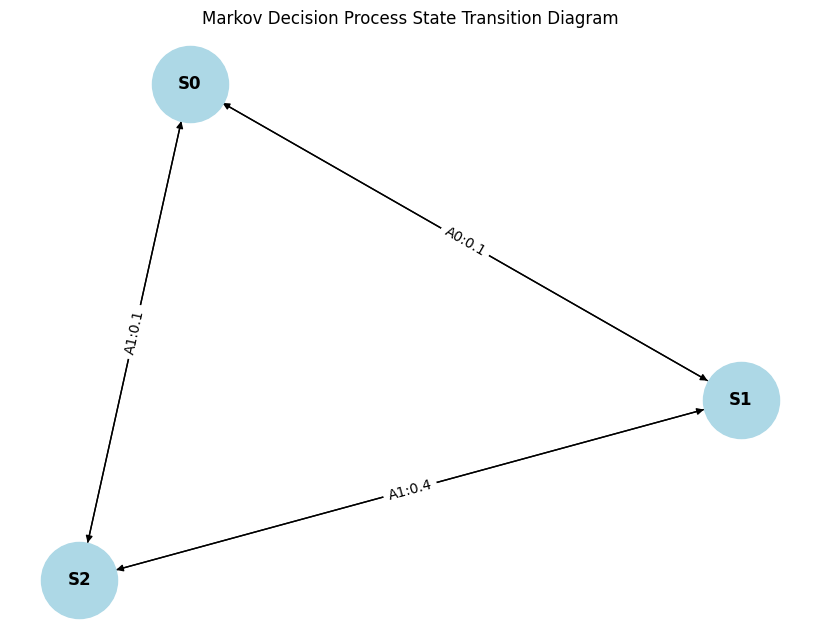

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G = nx.DiGraph()

# Add states
states = ["S0", "S1", "S2"]
G.add_nodes_from(states)

# Add transitions
G.add_edge("S0", "S1", label="A0:0.2")
G.add_edge("S0", "S2", label="A0:0.1")
G.add_edge("S1", "S0", label="A0:0.1")
G.add_edge("S1", "S2", label="A1:0.2")
G.add_edge("S2", "S0", label="A1:0.1")
G.add_edge("S2", "S1", label="A1:0.4")

# Draw graph
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=12,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, "label")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Markov Decision Process State Transition Diagram")
plt.show()

## Interpretation

The state transition graph shows how the agent moves between states based on actions and transition probabilities. Based on the expected rewards, the best actions are A0 for S0 and S1, and A1 for S2.


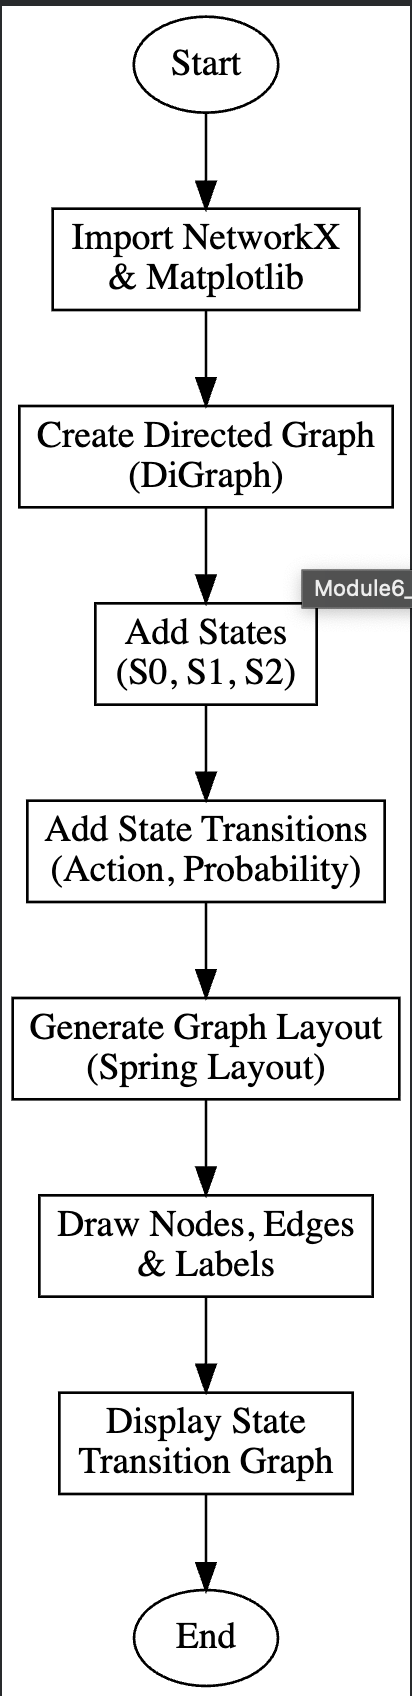